<a href="https://colab.research.google.com/github/AngeloSorte/Global_Meteorite_and_NEO_Risk_Study/blob/angelosorte.github.io/NEO_API_Data_Extraction_and_Preliminary_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 47.5 MB/s eta 0:00:00
Data fetched for NEOs from 2025-05-22 to 2025-05-28
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 18 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   id                                                    82 non-null     object 
 1   neo_reference_id                                      82 non-null     object 
 2   name                                                  82 non-null     object 
 3   nasa_jpl_url                                          82 non-null     object 
 4   absolute_magnitude_h                                  82 non-null     float64
 5   is_potentially_hazardous_asteroid                     82 non-null     bool   
 6   close_approach_data                                   82 non-null     object 
 7   is_sentry_object

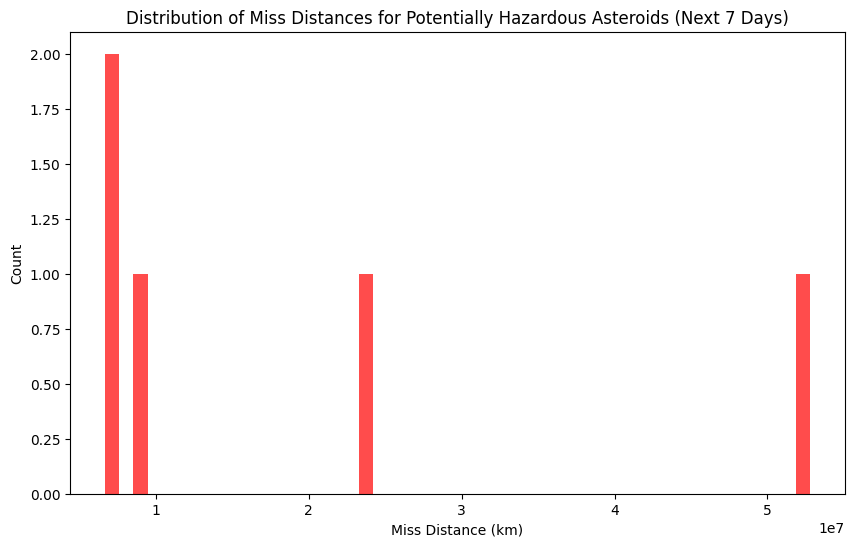

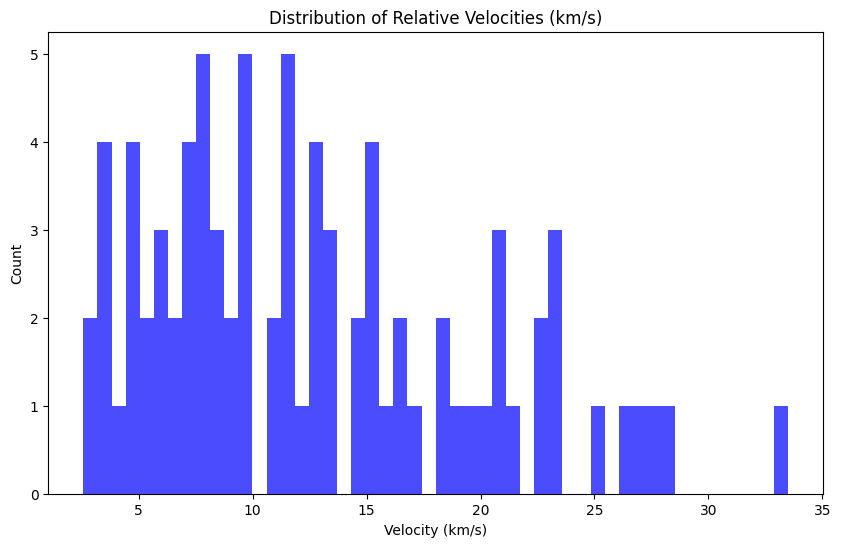

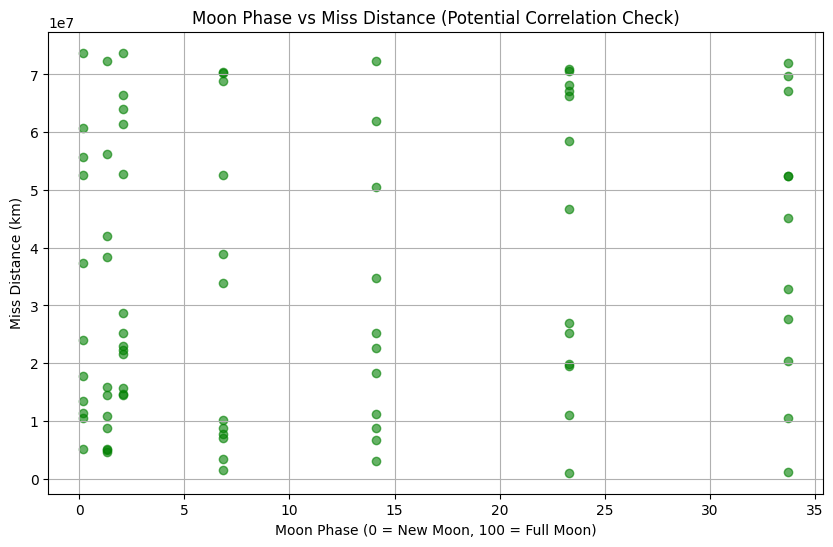

Summary Statistics:
       miss_distance_km  relative_velocity_km_per_s  moon_phase
count      8.200000e+01                   82.000000   82.000000
mean       3.428876e+07                   12.721094   11.645768
std        2.449256e+07                    7.123576   11.801344
min        1.023922e+06                    2.568230    0.194761
25%        1.123084e+07                    7.099643    1.332861
50%        2.613115e+07                   11.433621    6.835179
75%        5.791633e+07                   17.114440   23.314526
max        7.375512e+07                   33.489117   33.718620


In [2]:
# Install ephem if not present
!pip install ephem

# Import necessary libraries
import requests
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import ephem

# Your NASA API key
API_KEY = "DohXdJ9ghQ0AHpcdkgo7leD8QBsKhjyCiFIKZj3Y"

# Base URL for NASA NEO (Near Earth Object) Feed API - to get data for a date range
BASE_URL = "https://api.nasa.gov/neo/rest/v1/feed"

# Define dynamic date range (today to today+6)
start_date = datetime.date.today()
end_date = start_date + datetime.timedelta(days=6)

# Parameters for the request
params = {
    "start_date": start_date.isoformat(),
    "end_date": end_date.isoformat(),
    "api_key": API_KEY
}

# Fetch data from NASA NEO API
response = requests.get(BASE_URL, params=params)
data = response.json()

# Extract Near Earth Object data
neos = []
for date in data['near_earth_objects']:
    neos += data['near_earth_objects'][date]

# Convert to DataFrame
df = pd.json_normalize(neos)

# Display basic info
print("Data fetched for NEOs from {} to {}".format(start_date, end_date))
print(df.info())
print(df.head())

# Extract important columns
cols_of_interest = [
    'id', 'name', 'absolute_magnitude_h', 'estimated_diameter.kilometers.estimated_diameter_min',
    'estimated_diameter.kilometers.estimated_diameter_max', 'is_potentially_hazardous_asteroid',
    'close_approach_data'
]
df_neos = df[cols_of_interest]

# Flatten close_approach_data (take first approach per object)
def extract_approach_info(cad_list):
    if cad_list:
        cad = cad_list[0]
        return pd.Series({
            'close_approach_date': cad['close_approach_date'],
            'relative_velocity_km_per_s': cad['relative_velocity']['kilometers_per_second'],
            'miss_distance_km': cad['miss_distance']['kilometers'],
            'orbiting_body': cad['orbiting_body']
        })
    else:
        return pd.Series({
            'close_approach_date': None,
            'relative_velocity_km_per_s': None,
            'miss_distance_km': None,
            'orbiting_body': None
        })

approach_df = df_neos['close_approach_data'].apply(extract_approach_info)

# Merge with main DataFrame
df_neos = pd.concat([df_neos.drop(columns=['close_approach_data']), approach_df], axis=1)

# Convert types
df_neos['close_approach_date'] = pd.to_datetime(df_neos['close_approach_date'])
df_neos['relative_velocity_km_per_s'] = pd.to_numeric(df_neos['relative_velocity_km_per_s'])
df_neos['miss_distance_km'] = pd.to_numeric(df_neos['miss_distance_km'])

# Add Moon phase
def get_moon_phase(date):
    observer = ephem.Observer()
    observer.date = date
    moon = ephem.Moon(observer)
    return moon.phase  # 0-100: 0=new moon, 100=full moon

df_neos['moon_phase'] = df_neos['close_approach_date'].apply(lambda x: get_moon_phase(x) if pd.notnull(x) else None)

# Show cleaned DataFrame
print(df_neos.head())

# Save to CSV
df_neos.to_csv("neo_data_dynamic.csv", index=False)

# Plot: Distribution of miss distances for potentially hazardous asteroids
plt.figure(figsize=(10,6))
hazardous = df_neos[df_neos['is_potentially_hazardous_asteroid'] == True]
plt.hist(hazardous['miss_distance_km'].dropna(), bins=50, color='red', alpha=0.7)
plt.title("Distribution of Miss Distances for Potentially Hazardous Asteroids (Next 7 Days)")
plt.xlabel("Miss Distance (km)")
plt.ylabel("Count")
plt.show()

# Plot: Distribution of relative velocities
plt.figure(figsize=(10,6))
plt.hist(df_neos['relative_velocity_km_per_s'].dropna(), bins=50, color='blue', alpha=0.7)
plt.title("Distribution of Relative Velocities (km/s)")
plt.xlabel("Velocity (km/s)")
plt.ylabel("Count")
plt.show()

# Plot: Moon Phase vs Miss Distance (scatter)
plt.figure(figsize=(10,6))
plt.scatter(df_neos['moon_phase'], df_neos['miss_distance_km'], c='green', alpha=0.6)
plt.title("Moon Phase vs Miss Distance (Potential Correlation Check)")
plt.xlabel("Moon Phase (0 = New Moon, 100 = Full Moon)")
plt.ylabel("Miss Distance (km)")
plt.grid(True)
plt.show()

# Summary stats
print("Summary Statistics:")
print(df_neos[['miss_distance_km', 'relative_velocity_km_per_s', 'moon_phase']].describe())
